- get rnn trajectories
- get the first two time points
- look at contrasts other than 0
-  left/right, correct/incorrect, congruent/incongruent

In [3]:
from decision_rnn.utils import (
    run_single_session,
    load_checkpoint_and_model,
)
import decision_rnn.models.bayesian as Bb
from decision_rnn.train import step_through_environment
import torch
import numpy as np
import pandas as pd
import pickle as pkl
from matplotlib import pyplot as plt
from decision_rnn.ibl_env import IBLSessionfix, IBLSessionflex
from decision_rnn.models.model import CustomGRU
from tqdm import tqdm
from decision_rnn.generate_session_data_quiscience import adjust_rnn_indices
from decision_rnn.utils import add_congruency_incongruency
from decision_rnn.models.behavior_utils import add_bayes_prior
import seaborn as sns

from decision_rnn.information_measures.processing import (
    hidden_layer_binning_equipopulated,
    prepare_te_inputs,
    equipopulated_binning,
)
from decision_rnn.analysis.fixed_time_gru import (
    discretize_all_timesteps,
    mi_hidden_vs_target,
    pid_hidden_pairs,
    compute_te_with_condition,
)
from sklearn.decomposition import PCA

In [4]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


def get_category_centroids(data, combine_contrasts=False):
    """
    Calculates the mean hidden state (centroid) for each of the 8 trial categories.
    """
    results = {}

    if combine_contrasts:
        # Concatenate arrays across all contrasts
        combined_data = {
            "correct": np.concatenate([np.asarray(data[c]["correct"]) for c in data]),
            "trial_side": np.concatenate([np.asarray(data[c]["trial_side"]) for c in data]),
            "block_side": np.concatenate([np.asarray(data[c]["block_side"]) for c in data]),
            "hidden_state_seq": np.concatenate(
                [np.asarray(data[c]["hidden_state_seq"]) for c in data], axis=0
            ),
        }
        results["all_contrasts"] = _compute_centroids(combined_data)
    else:
        # Process each contrast individually
        for contrast, contrast_data in data.items():
            results[contrast] = _compute_centroids(contrast_data)

    return results


def _compute_centroids(contrast_data):
    """Helper function to apply logical masks and compute the mean hidden state."""

    correct = contrast_data["correct"] == 1
    left_stim = contrast_data["trial_side"] == -1
    left_block = contrast_data["block_side"] == -1

    conditions = {
        "ls_lb_correct": left_stim & left_block & correct,
        "ls_rb_correct": left_stim & ~left_block & correct,
        "rs_lb_correct": ~left_stim & left_block & correct,
        "rs_rb_correct": ~left_stim & ~left_block & correct,
        "ls_lb_incorrect": left_stim & left_block & ~correct,
        "ls_rb_incorrect": left_stim & ~left_block & ~correct,
        "rs_lb_incorrect": ~left_stim & left_block & ~correct,
        "rs_rb_incorrect": ~left_stim & ~left_block & ~correct,
    }

    hs_full = contrast_data["hidden_state_seq"][:, 0, :].squeeze()

    centroids = {}
    for name, mask in conditions.items():
        # Check if there are any trials for this condition to avoid Mean of Empty Slice warnings
        if np.any(mask):
            # Calculate the mean across the trials dimension (axis 0)
            centroids[name] = np.mean(hs_full[mask], axis=0)
        else:
            centroids[name] = None  # No trials for this specific condition

    return centroids


def plot_centroids(centroids_dict, contrast_key="all_contrasts"):
    """
    Plots the 3D centroids of the hidden states for a specific contrast.
    """
    if contrast_key not in centroids_dict:
        print(f"Error: '{contrast_key}' not found. Available keys: {list(centroids_dict.keys())}")
        return

    centroids = centroids_dict[contrast_key]

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    color_map = {"ls_lb": "blue", "ls_rb": "cyan", "rs_lb": "red", "rs_rb": "magenta"}

    for condition, point in centroids.items():
        if point is None:
            continue  # Skip if no data for this condition

        base_cond = condition.replace("_correct", "").replace("_incorrect", "")
        color = color_map.get(base_cond, "gray")

        is_correct = "incorrect" not in condition
        marker = "o" if is_correct else "X"

        ax.scatter(
            point[0],
            point[1],
            point[2],
            c=color,
            marker=marker,
            s=200,
            edgecolors="black",
            label=condition,
        )

        # Add a text label slightly offset from the point
        label_text = condition.replace("_", " ")
        ax.text(point[0] + 0.05, point[1] + 0.05, point[2] + 0.05, label_text, fontsize=9)
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(-0.8, 0.8)
        ax.set_zlim(-0.8, 0.8)

    ax.set_title(f"Category Centroids in 3D Hidden State Space ({contrast_key})", fontsize=14)
    ax.set_xlabel("Hidden State 1")
    ax.set_ylabel("Hidden State 2")
    ax.set_zlabel("Hidden State 3")

    # Legend mapping
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Conditions")
    # plt.tight_layout()
    plt.show()


def plot_centroids_subplots(centroids_dict):
    """
    Plots the 3D centroids for each contrast on a separate subplot.

    Args:
        centroids_dict (dict): The output from get_category_centroids(data, combine_contrasts=False).
    """

    n_contrasts = len(centroids_dict)
    if n_contrasts == 0:
        print("Error: The centroids dictionary is empty.")
        return

    cols = int(np.ceil(np.sqrt(n_contrasts)))
    rows = int(np.ceil(n_contrasts / cols))

    fig = plt.figure(figsize=(6 * cols, 5 * rows))

    color_map = {"ls_lb": "blue", "ls_rb": "cyan", "rs_lb": "red", "rs_rb": "magenta"}

    handles, labels = [], []

    for i, (contrast_name, centroids) in enumerate(centroids_dict.items(), 1):
        ax = fig.add_subplot(rows, cols, i, projection="3d")
        ax.set_title(f"Contrast: {contrast_name}", fontsize=12)

        for condition, point in centroids.items():
            if point is None:
                continue

            base_cond = condition.replace("_correct", "").replace("_incorrect", "")
            color = color_map.get(base_cond, "gray")

            is_correct = "incorrect" not in condition
            marker = "o" if is_correct else "X"

            scatter = ax.scatter(
                point[0],
                point[1],
                point[2],
                c=color,
                marker=marker,
                s=150,
                edgecolors="black",
                label=condition,
            )

            # Add short text labels to avoid overcrowding the subplots
            short_label = condition.replace("_correct", " (C)").replace("_incorrect", " (X)")
            ax.text(point[0], point[1], point[2] + 0.05, short_label, fontsize=8)

            # Collect handles for the global legend (only from the first subplot)
            if i == 1:
                handles.append(scatter)
                labels.append(condition)

            ax.set_xlim(-0.8, 0.8)
            ax.set_ylim(-0.8, 0.8)
            ax.set_zlim(-0.8, 0.8)
        # Basic axis labels for each subplot
        ax.set_xlabel("HS 1")
        ax.set_ylabel("HS 2")
        ax.set_zlabel("HS 3")

    # Add a single global legend to the right of the entire figure
    if handles:
        fig.legend(
            handles, labels, loc="center right", title="Conditions", bbox_to_anchor=(1.1, 0.5)
        )

    plt.tight_layout()
    plt.show()


import numpy as np
from sklearn.decomposition import PCA


def get_2d_pca_centroids(data):
    """
    Fits a global 2D PCA across all trials, computes condition centroids,
    and projects them into the shared 2D space.
    """

    all_hidden_states = []
    for contrast, contrast_data in data.items():
        hs = np.asarray(contrast_data["hidden_state_seq"])

        hs_2d = hs.reshape(hs.shape[0], -1)
        all_hidden_states.append(hs_2d)

    combined_hs = np.vstack(all_hidden_states)

    pca = PCA(n_components=2)
    pca.fit(combined_hs)
    explained_var = pca.explained_variance_ratio_

    results = {}
    for contrast, contrast_data in data.items():
        correct = np.asarray(contrast_data["correct"]) == 1
        left_stim = np.asarray(contrast_data["trial_side"]) == -1
        left_block = np.asarray(contrast_data["block_side"]) == -1

        conditions = {
            "ls_lb_correct": left_stim & left_block & correct,
            "ls_rb_correct": left_stim & ~left_block & correct,
            "rs_lb_correct": ~left_stim & left_block & correct,
            "rs_rb_correct": ~left_stim & ~left_block & correct,
            "ls_lb_incorrect": left_stim & left_block & ~correct,
            "ls_rb_incorrect": left_stim & ~left_block & ~correct,
            "rs_lb_incorrect": ~left_stim & left_block & ~correct,
            "rs_rb_incorrect": ~left_stim & ~left_block & ~correct,
        }

        hs_full = np.asarray(contrast_data["hidden_state_seq"])
        hs_full_2d = hs_full.reshape(hs_full.shape[0], -1)

        centroids_2d = {}
        for name, mask in conditions.items():
            if np.any(mask):

                centroid_3d = np.mean(hs_full_2d[mask], axis=0)
                centroid_2d = pca.transform(centroid_3d.reshape(1, -1))[0]
                centroids_2d[name] = centroid_2d
            else:
                centroids_2d[name] = None

        results[contrast] = centroids_2d

    return results, explained_var


def plot_2d_centroids_subplots(centroids_dict, explained_var):
    """
    Plots the 2D PCA-projected centroids for each contrast on a separate subplot.
    """
    n_contrasts = len(centroids_dict)
    if n_contrasts == 0:
        print("Error: The centroids dictionary is empty.")
        return

    cols = int(np.ceil(np.sqrt(n_contrasts)))
    rows = int(np.ceil(n_contrasts / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    color_map = {"ls_lb": "blue", "ls_rb": "cyan", "rs_lb": "red", "rs_rb": "magenta"}

    handles, labels = [], []

    for i, ((contrast_name, centroids), ax) in enumerate(zip(centroids_dict.items(), axes)):
        ax.set_title(f"Contrast: {contrast_name}", fontsize=12)

        for condition, point in centroids.items():
            if point is None:
                continue

            base_cond = condition.replace("_correct", "").replace("_incorrect", "")
            color = color_map.get(base_cond, "gray")

            is_correct = "incorrect" not in condition
            is_congruent = base_cond in ["ls_lb", "rs_rb"]

            marker = "o" if is_correct else "X"

            if is_congruent:
                face_color = color  # Solid fill
                edge_color = "black"  # Standard black border
                line_width = 1.0
            else:
                face_color = "white"  # Hollow inside
                edge_color = color  # The border becomes the condition color
                line_width = 2.5  # Make the colored border thicker so it's easy to see

            scatter = ax.scatter(
                point[0],
                point[1],
                facecolors=face_color,
                edgecolors=edge_color,
                linewidths=line_width,
                marker=marker,
                s=150,
                label=condition,
            )

            # Add short text labels slightly offset
            short_label = condition.replace("_correct", " (C)").replace("_incorrect", " (W)")
            ax.text(point[0] + 0.02, point[1] + 0.02, short_label, fontsize=12)

            # 3. Fixed the index check (enumerate with zip starts at 0)
            if i == 0:
                handles.append(scatter)
                labels.append(condition)

        ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
        ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
        ax.grid(True, linestyle="--", alpha=0.5)

        ax.tick_params(labelbottom=True, labelleft=True)

    # Clean up empty subplots
    for j in range(len(centroids_dict), len(axes)):
        axes[j].set_visible(False)

    if handles:
        fig.legend(
            handles, labels, loc="center right", title="Conditions", bbox_to_anchor=(1.1, 0.5)
        )

    plt.tight_layout()
    sns.despine()
    plt.show()



In [53]:
with open(
    "../../custom-rnn/decision_rnn/data/processed/flowing-bush-151/checkpoint_70000_20250626152332.pkl",
    "rb",
) as f:
    data_engaged = pkl.load(f)

In [54]:
with open("../data/generated/rnn_engagement_level_1.0.pkl", "rb") as f:
    semi_engaged = pkl.load(f)

In [55]:
with open("../data/generated/rnn_engagement_level_173.pkl", "rb") as f:
    disengaged = pkl.load(f)

In [9]:
def plot_contrasts_separately_3d(data_x):

    separated_centroids = get_category_centroids(data_x, combine_contrasts=False)
    plot_centroids_subplots(separated_centroids)


def plot_contrasts_separately_2d(data_x):
    centroids_2d, explained_variance = get_2d_pca_centroids(data_x)
    plot_2d_centroids_subplots(centroids_2d, explained_variance)

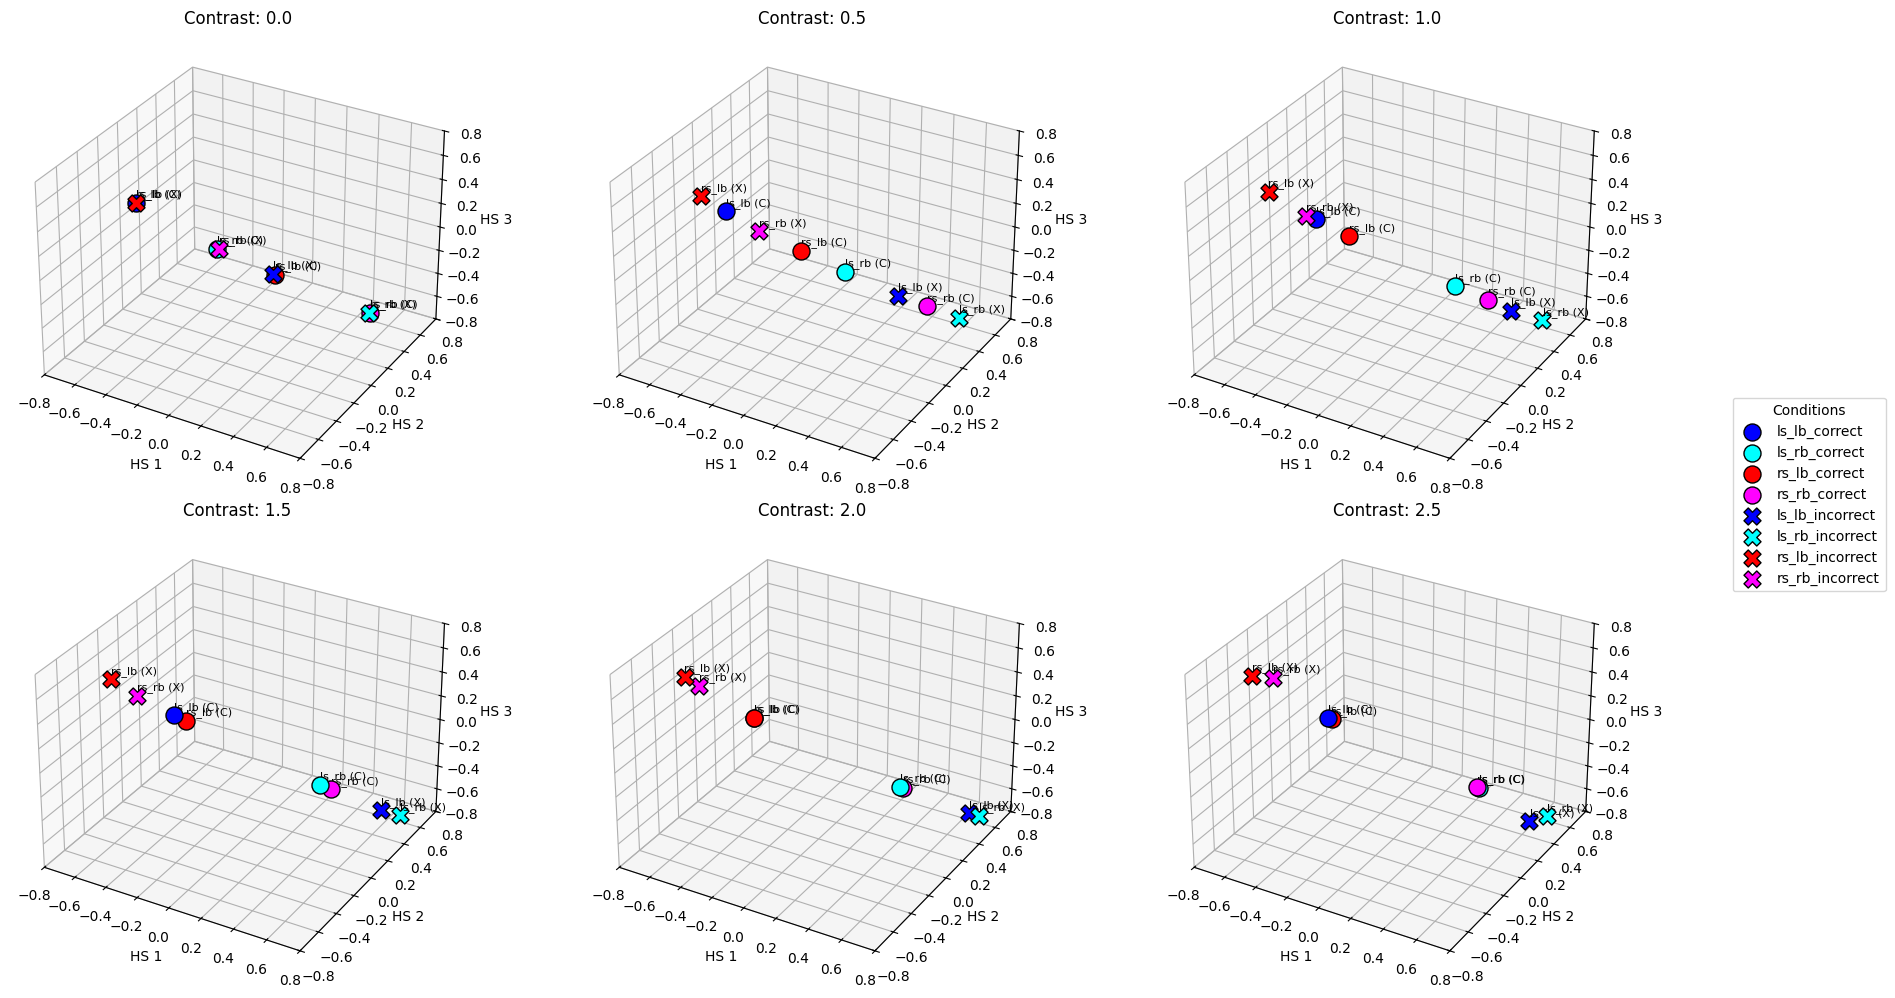

In [10]:
plot_contrasts_separately_3d(data_x=data_engaged)

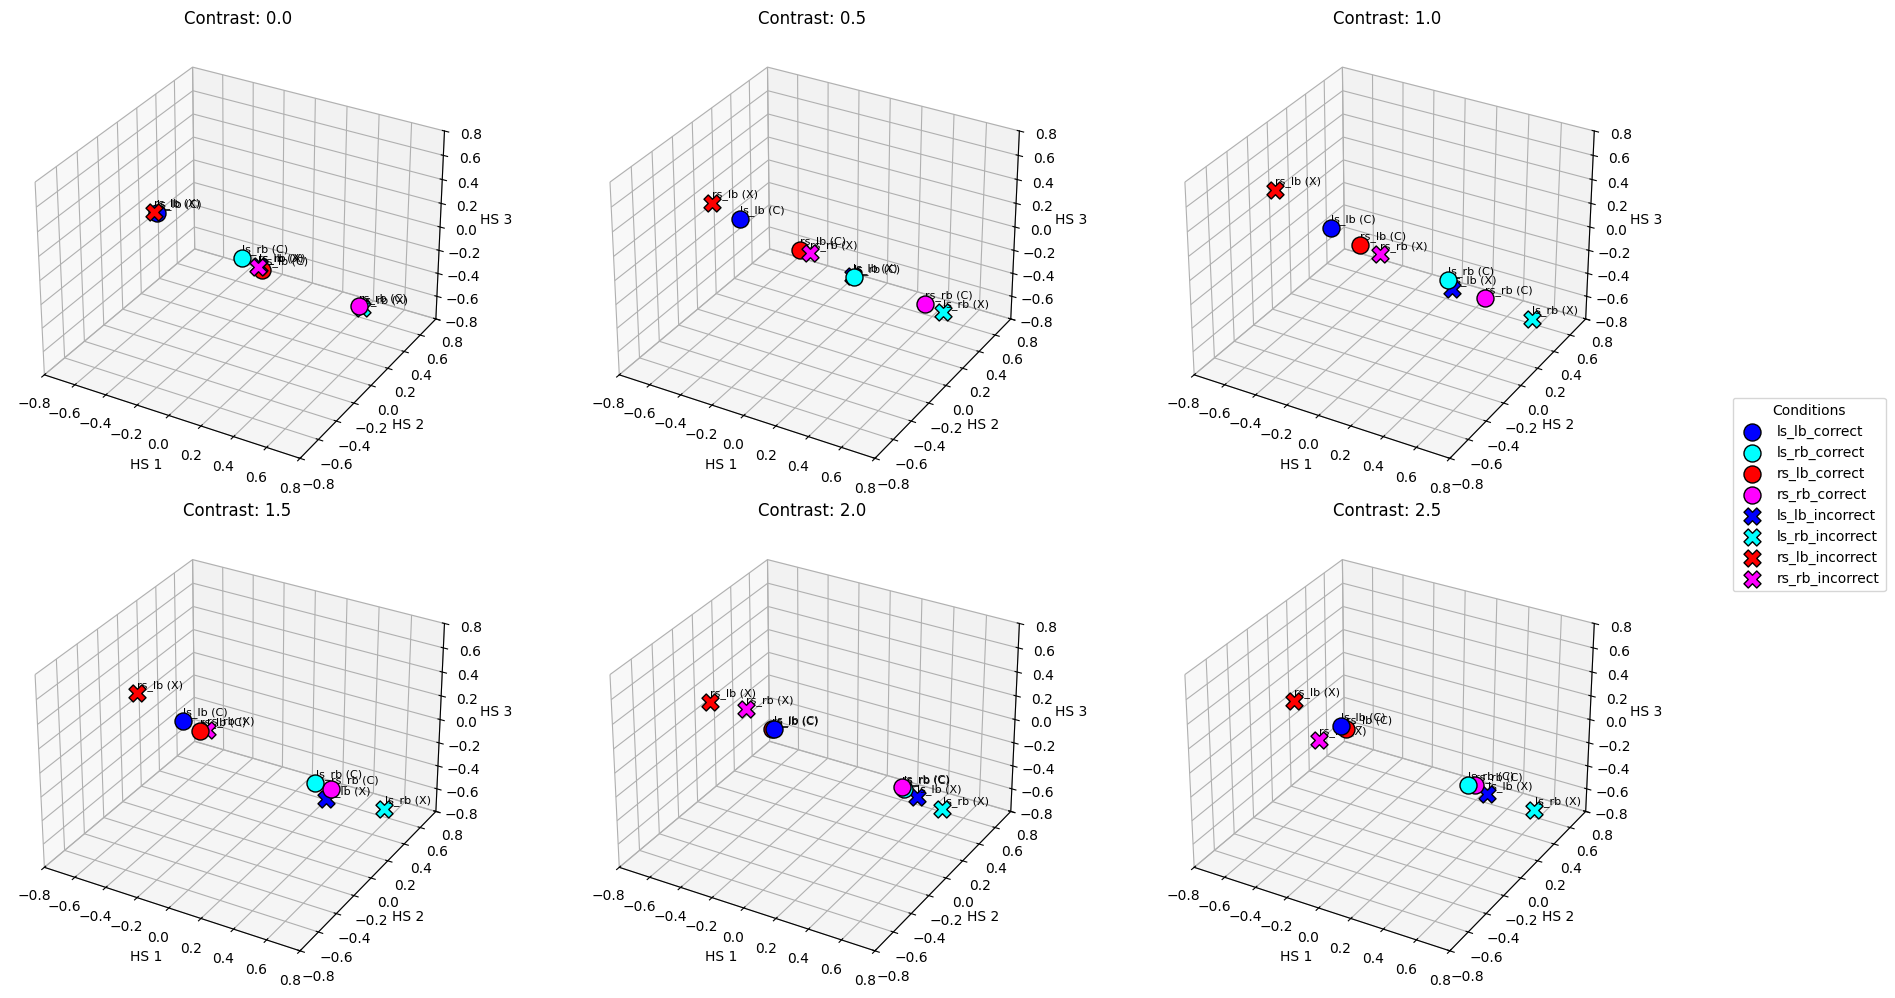

In [11]:
plot_contrasts_separately_3d(data_x=semi_engaged)

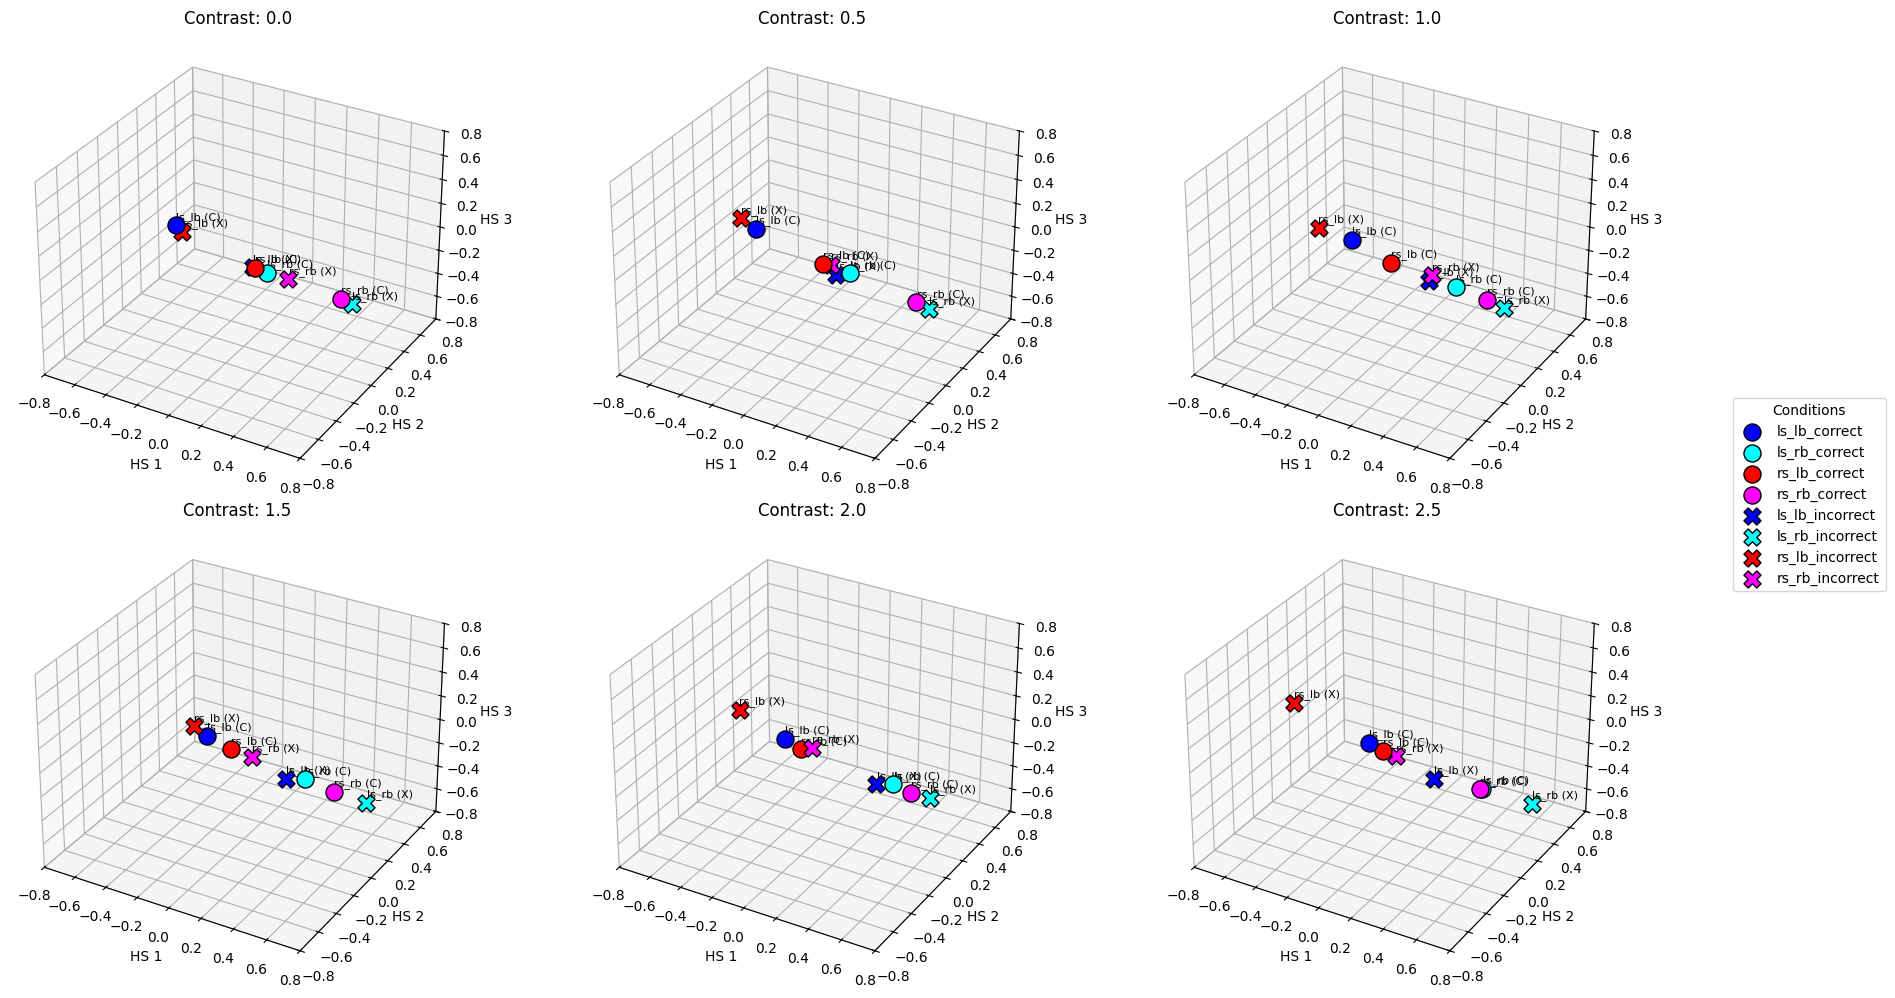

In [12]:
plot_contrasts_separately_3d(data_x=disengaged)

In [49]:
predict_choice_from_start_state(data=data_engaged)

Mean Choice Prediction Accuracy from t=0: 74.0%


(LogisticRegression(),
 array([[-0.23550628, -0.22800285, -0.20495892],
        [-0.6951107 , -0.32445005,  0.59174633],
        [-0.5834629 , -0.27787405,  0.47334695],
        ...,
        [-0.7147857 , -0.33461446,  0.6073779 ],
        [ 0.73114896,  0.35006   , -0.34280732],
        [ 0.8271947 ,  0.35293084, -0.4744627 ]], dtype=float32),
 array([ 1., -1., -1., ...,  1., -1.,  1.], dtype=float32))

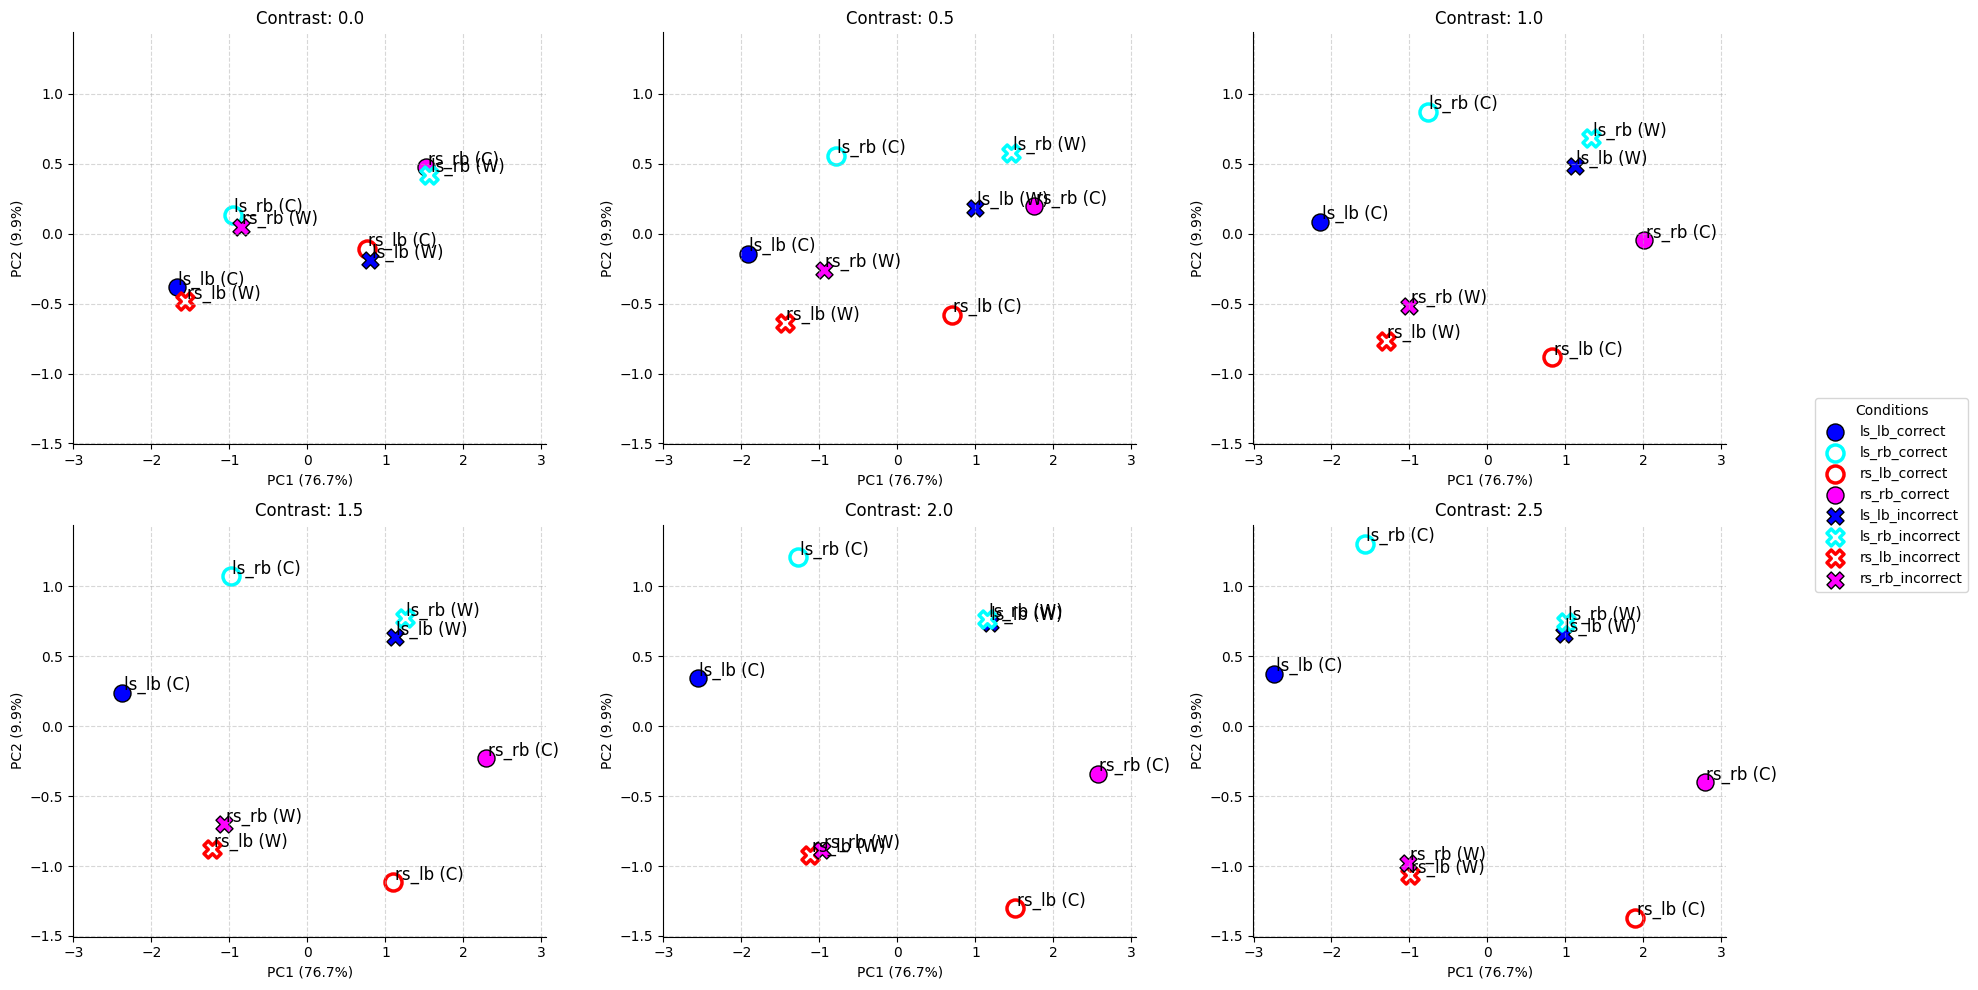

In [50]:
plot_contrasts_separately_2d(data_engaged)

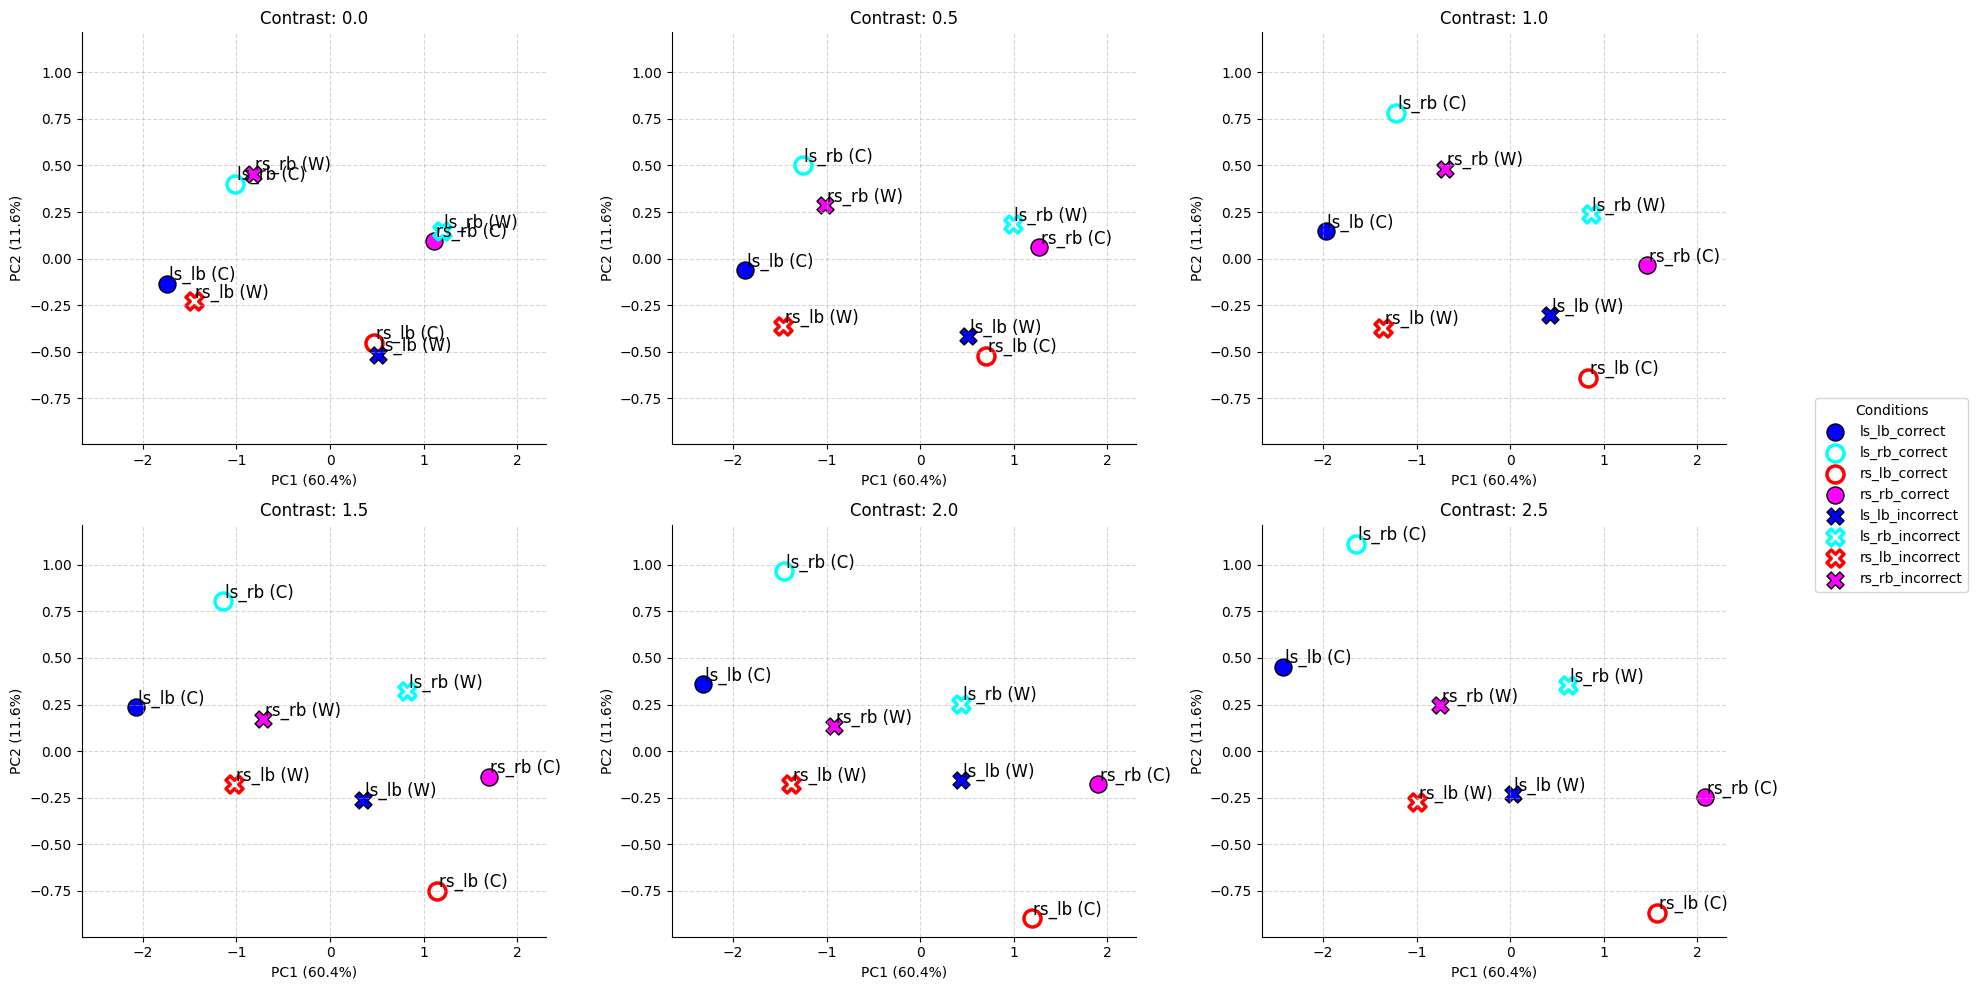

In [51]:
plot_contrasts_separately_2d(disengaged)

In [16]:
# plot percentage corrects

In [17]:
contrast_data = data_engaged[0.5]

In [18]:
def return_percentage_corrects(data):

    percentages = []
    for k in data.keys():

        contrast_data = data[k]
        correct = np.asarray(contrast_data["correct"]) == 1
        left_stim = np.asarray(contrast_data["trial_side"]) == -1
        left_block = np.asarray(contrast_data["block_side"]) == -1
        congruent = left_stim == left_block

        conditions = {
            "congruent_correct": congruent & correct,
            "congruent_incorrect": congruent & ~correct,
            "incongruent_correct": ~congruent & correct,
            "incongruent_incorrect": ~congruent & ~correct,
        }

        percentages.append(
            [
                np.sum(conditions["congruent_correct"]) / np.sum(congruent),
                np.sum(conditions["incongruent_correct"]) / np.sum(~congruent),
            ]
        )
    return np.asarray(percentages)

In [19]:
fraction_correct_engaged = return_percentage_corrects(data_engaged)
fraction_correct_disengaged = return_percentage_corrects(disengaged)
fraction_correct_medium = return_percentage_corrects(semi_engaged)

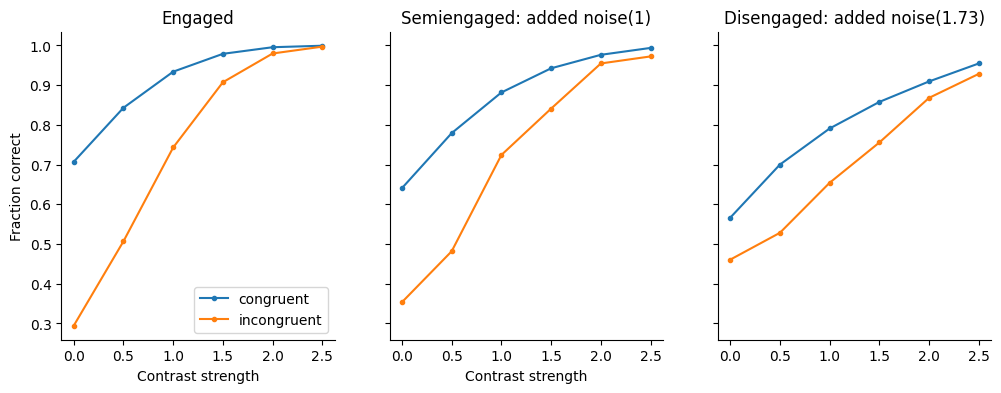

In [20]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=3, sharex=True, sharey=True)
ax[0].plot(np.arange(6), fraction_correct_engaged[:, 0], label="congruent", marker=".")
ax[0].plot(np.arange(6), fraction_correct_engaged[:, 1], label="incongruent", marker=".")
ax[1].plot(np.arange(6), fraction_correct_medium[:, 0], label="congruent", marker=".")
ax[1].plot(np.arange(6), fraction_correct_medium[:, 1], label="incongruent", marker=".")
ax[2].plot(np.arange(6), fraction_correct_disengaged[:, 0], label="congruent", marker=".")
ax[2].plot(np.arange(6), fraction_correct_disengaged[:, 1], label="incongruent", marker=".")
ax[0].legend()
ax[0].set_ylabel("Fraction correct")
ax[0].set_xlabel("Contrast strength")
ax[1].set_xlabel("Contrast strength")
ax[0].set_xticks(np.arange(6), np.linspace(0, 2.5, 6))
ax[0].set_title("Engaged")
ax[1].set_title("Semiengaged: added noise(1)")
ax[2].set_title("Disengaged: added noise(1.73)")
sns.despine()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


def plot_dprime_distributions():

    mu_values = np.linspace(0, 2.5, 6)
    sigma_engaged = 1.0
    sigma_disengaged = 2

    fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    x = np.linspace(-6, 8, 1000)

    for i, mu in enumerate(mu_values):
        ax = axes[i]

        d_prime_eng = mu / sigma_engaged
        d_prime_dis = mu / sigma_disengaged

        noise_eng = stats.norm.pdf(x, loc=0, scale=sigma_engaged)
        signal_eng = stats.norm.pdf(x, loc=mu, scale=sigma_engaged)

        ax.plot(
            x,
            noise_eng,
            color="black",
            linestyle="-",
            linewidth=2,
            label="Noise:Engaged",
        )
        ax.plot(
            x,
            signal_eng,
            color="blue",
            linestyle="-",
            linewidth=2,
            label="Signal:Engaged",
        )

        min_curve_eng = np.minimum(noise_eng, signal_eng)
        ax.fill_between(x, min_curve_eng, color="blue", alpha=0.1)

        noise_dis = stats.norm.pdf(x, loc=0, scale=sigma_disengaged)
        signal_dis = stats.norm.pdf(x, loc=mu, scale=sigma_disengaged)

        ax.plot(
            x,
            noise_dis,
            color="gray",
            linestyle="--",
            linewidth=2,
            label=f"Noise:Disengaged",
        )
        ax.plot(
            x,
            signal_dis,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Signal:Disengaged",
        )

        title_text = f"Contrast: {mu:.1f}\n" f"$d_e'={d_prime_eng:.2f}$ |$d_d'={d_prime_dis:.2f}$"
        ax.set_title(title_text, fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.4)

        if i == 0:
            ax.legend(loc="upper right", fontsize=9)

    # Global labels
    fig.text(0.5, 0.02, "Stimulus Integration Value", ha="center", fontsize=14)
    fig.text(0.02, 0.5, "Probability Density", va="center", rotation="vertical", fontsize=14)

    sns.despine()
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
    plt.suptitle(
        "Impact of Engagement State on Signal-to-Noise Ratio (d')", fontsize=16, fontweight="bold"
    )
    plt.show()


# Run the function
plot_dprime_distributions()

In [22]:
# ompute distances

In [30]:
centroids_2d_engaged, explained_variance_engaged = get_2d_pca_centroids(data_engaged)
centroids_2d_disengaged, explained_variance_disengaged = get_2d_pca_centroids(disengaged)

In [31]:
from scipy.spatial import distance

In [32]:
def compute_distances(centroids):
    d_left_trap = distance.euclidean(centroids["ls_lb_correct"], centroids["rs_lb_incorrect"])
    d_right_trap = distance.euclidean(centroids["rs_rb_correct"], centroids["ls_rb_incorrect"])

    d_prior = distance.euclidean(centroids["ls_lb_correct"], centroids["rs_rb_correct"])
    d_outcome = distance.euclidean(centroids["ls_lb_correct"], centroids["ls_lb_incorrect"])

    return d_prior, d_outcome, d_left_trap, d_right_trap

In [46]:
def distance_plots(centroids_engaged, centroids_disengaged, contrast):
    distances = np.zeros((2, 4))

    distances[0, :] = compute_distances(centroids_engaged[contrast])
    distances[1, :] = compute_distances(centroids_disengaged[contrast])

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(distances, cmap="viridis", annot=True)
    ax.set_yticklabels(["Engaged", "Disengaged"])
    ax.set_xticklabels(
        [
            "Left_Congruent-Right_Congruent (correct)",
            "Left_Congruent(correct)-Left_Congruent(incorrect)",
            "Left_Congruent (correct)-Right_Incongruent(incorrect)",
            "Right_Congruent(correct)-Left_Incongruent(incorrect)",
        ],
        rotation=90,
    )
    ax.set_title(f"{contrast}")

In [ ]:
for c in np.linspace(0, 2.5, 6):
    distance_plots(centroids_2d_engaged, centroids_2d_disengaged, c)

In [76]:
def predict_choice_from_start_state(data):
    """
    Trains a classifier to predict the final choice from the t=0 hidden state.
    """
    all_hs = []
    all_choices = []
    contrast_wise_accuracy = []
    for contrast, contrast_data in data.items():
        # Get starting states (t=0) and flatten extra dimensions
        hs_start = np.asarray(contrast_data["hidden_state_seq"])[:, 0, :]
        hs_start = hs_start.reshape(hs_start.shape[0], -1)

        choices = contrast_data["action_side"]

        all_hs.append(hs_start)
        all_choices.append(choices)

        clf_ = LogisticRegression()

        X_ = np.asarray(hs_start).reshape(-1, 3)
        Y_ = np.asarray(choices).reshape(-1)

        # print(X_.shape, Y_.shape)
        scores = cross_val_score(clf_, X_, Y_, cv=5)

        # print(f"Mean Choice Prediction Accuracy for {contrast}: {np.mean(scores)*100:.1f}%")
        contrast_wise_accuracy.append([np.mean(scores), np.std(scores)])

    X = np.vstack(all_hs)
    y = np.concatenate(all_choices)

    clf = LogisticRegression()
    scores = cross_val_score(clf, X, y, cv=5)

    # print(f"Mean Choice Prediction Accuracy from t=0: {np.mean(scores)*100:.1f}%")
    return np.asarray(contrast_wise_accuracy), np.mean(scores)

In [77]:
contrast_accuracy_engaged, mean_engaged = predict_choice_from_start_state(data=data_engaged)

In [78]:
contrast_accuracy_disengaged, mean_disengaged = predict_choice_from_start_state(data=disengaged)

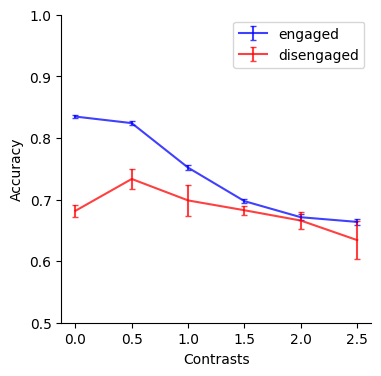

In [100]:
fig, ax = plt.subplots(figsize=(4, 4), ncols=1, sharey=True, sharex=True)
ax.errorbar(
    np.arange(6),
    contrast_accuracy_engaged[:, 0],
    yerr=contrast_accuracy_engaged[:, 1],
    capsize=2,
    color="blue",
    alpha=0.75,
    label="engaged",
)
ax.errorbar(
    np.arange(6),
    contrast_accuracy_disengaged[:, 0],
    yerr=contrast_accuracy_disengaged[:, 1],
    capsize=2,
    color="red",
    alpha=0.75,
    label="disengaged",
)
sns.despine()
ax.set_ylim(0.5, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Contrasts")
ax.set_xticks(np.arange(6), np.linspace(0, 2.5, 6))
ax.legend()